# Dataset Construction Corrected

Dataset construction notebook that only seeks to compute the max landfalling SLP gradient column, since this had a bug.

In [1]:
# load external packages
import os
import pandas as pd
import xarray as xr
from pathlib import Path
import earthaccess
import ray
from tqdm import tqdm
from huggingface_hub import login, HfApi
import logging
import sys

In [2]:
# load artools
import artools
from artools.loading_utils import load_ais, load_cell_areas, EarthdataGatekeeper, load_catalog
from artools.display_utils import display_catalog
from artools.attribute_utils import *
from artools.compute_attributes_streaming import *

/home/jovyan/extreme_antarctic_ARs/notebooks


In [3]:
OUTPUT_DIR = '../outputs/data_products'
NUM_CPUS = 15
CHUNK_SIZE = 10
BATCH_SIZE = 15

In [4]:
login()

In [5]:
# load the catalog
storms = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
# take only those that are landfalling
storms = storms[storms.is_landfalling]

In [6]:
storms['duration'] = storms['data_array'].apply(compute_duration)

In [7]:
sorted_storms = storms.sort_values(by='duration', ascending=False)

In [8]:
ais_mask = load_ais()
cell_areas = load_cell_areas()

In [9]:
data_dois = {'climatology': '10.5067/5ESKGQTZG7FO',
             'T2M_TQV_SLP': '10.5067/3Z173KIE2TPD',
             'VFLXQV_PRECIP': '10.5067/Q5GVUVUIVGO7',
             'V850': '10.5067/VJAFPLI1CSIV',
             'OMEGA': '10.5067/QBZ6MG944HW0'}

In [10]:
num_cpus = NUM_CPUS

# initialize ray cluster
ray.init(num_cpus=num_cpus, logging_level='ERROR', 
         _metrics_export_port=-1, include_dashboard=False, 
         log_to_driver=False, runtime_env={'py_modules': [artools.attribute_utils, artools.loading_utils]})

# put the climatologies and cell areas in the ray object store
cell_areas_ref = ray.put(cell_areas)
# prevents parallel open requests from being made to NASA servers
gatekeeper = EarthdataGatekeeper.remote()

/srv/conda/envs/notebook/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [11]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('../outputs/logs/dataset_construction_fixed_SLP.log')
    ],
    force=True
)
logging.info("Starting notebook background execution...")

2026-08-06 21:11:05,455 - INFO - Starting notebook background execution...


In [ ]:
func_vars_dict = {'SLP': {'max_ocean_SLP_gradient': lambda storm_da, var_da, area_da: 
                              compute_max_SLPgrad(storm_da, var_da, area_da, ais_mask)}}

func_vars_dict_ref = ray.put(func_vars_dict)

data_doi = data_dois['T2M_TQV_SLP']
# list with the computed results
results_SLP = []

chunk_size = CHUNK_SIZE
# split dataset of storms into chunks
chunks = [sorted_storms[i:i + chunk_size] for i in range(0, sorted_storms.shape[0], chunk_size)]
# number of chunks, i.e. tasks, to complete
batch_size = BATCH_SIZE

logging.info(f"Starting SLP computations in batches...")

for i in range(0, len(chunks), batch_size):
    batch_chunks = chunks[i:i + batch_size]
    
    # submit only this batch of tasks to ray
    batch_refs = [
        compute_chunk_summaries.remote(
            chunk,
            func_vars_dict_ref,
            cell_areas_ref,
            data_doi,
            gatekeeper=gatekeeper
        ) for chunk in batch_chunks
    ]
    
    # gather this batch's results and immediately clean up memory
    for j, ref in enumerate(batch_refs):
        results = ray.get(ref)
        results_SLP.extend(results)
        
        # clean up the reference immediately so ray empties the object store
        batch_refs[j] = None
        
    logging.info(f"SLP: Finished up to chunk {min(i + batch_size, len(chunks))}/{len(chunks)}")

logging.info("SLP computations complete.")

2026-08-06 21:11:05,467 - INFO - Starting SLP computations in batches...


In [ ]:
# construct and save dataframe
labels = [key for quantity_dict in func_vars_dict.values() for key in quantity_dict.keys()]
df_SLP = pd.DataFrame(results_SLP, columns=labels, index=sorted_storms.index)
df_SLP.to_csv(OUTPUT_DIR + '/results_SLP_corrected.csv')
logging.info("SLP results saved!")

In [23]:
ray.shutdown()

Let's first see how different the two columns even are.

In [15]:
new_slp = pd.read_csv(OUTPUT_DIR + '/results_SLP_corrected.csv', index_col='cluster')

In [16]:
new_slp

,max_ocean_SLP_gradient
cluster,
8834.0,4.985424
3839.0,5.845591
7373.0,4.714060
3997.0,4.170346
6619.0,10.016430
...,...
1246.0,3.676616
4372.0,4.754682
4378.0,4.666238


In [19]:
old_slp = pd.read_csv(OUTPUT_DIR + '/results_T2M_TQV_SLP.csv', index_col='cluster')['max_ocean_SLP_gradient']

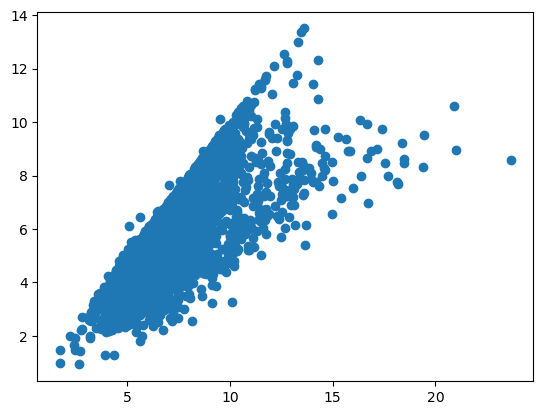

In [22]:
import matplotlib.pyplot as plt
plt.scatter(x=new_slp, y=old_slp)

Generally seems like the older values are smaller than the newer values.

Now, let's replace the SLP dataset column with the corrected one. We'll reproduce the preprocessing steps from the preprocessing notebook and ensure the train-test splits are the same, save for the SLP columns.

We'll drop the SLP column from `full_AR_df_old.h5`, which is the concatenation of all the results, first.

In [25]:
old_df = pd.read_hdf(OUTPUT_DIR + '/full_AR_df_old.h5', index_col='cluster')

In [28]:
new_df = old_df.drop(columns=['max_ocean_SLP_gradient'])
new_df = pd.concat([new_df, new_slp], axis=1)

In [30]:
no_ocean_component_SLP = new_df[new_df.max_ocean_SLP_gradient.isna()]
no_ocean_component_v850 = new_df[new_df.max_landfalling_v850hPa.isna()]

In [31]:
all(no_ocean_component_SLP.index == no_ocean_component_v850.index)

True

In [33]:
(no_ocean_component_SLP.shape[0], new_df.shape[0])

(83, 3165)

In [35]:
new_df = new_df[~new_df.max_ocean_SLP_gradient.isna()]

In [36]:
new_df.isna().any()

data_array                     False
is_landfalling                 False
max_area                       False
mean_landfalling_area          False
cumulative_landfalling_area    False
duration                       False
start_date                     False
end_date                       False
max_south_extent               False
region                         False
max_T2M_anomaly_ais            False
max_IWV_ais                    False
max_IWV_anomaly_ais            False
cumulative_rainfall_ais        False
cumulative_snowfall_ais        False
avg_landfalling_minomega       False
max_landfalling_v850hPa        False
max_vIVT_ais                   False
max_ocean_SLP_gradient         False
dtype: bool

In [37]:
df_no_dataarrays = new_df.drop(columns=['data_array'])

In [38]:
df_no_dataarrays.describe()

,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2M_anomaly_ais,max_IWV_ais,max_IWV_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,max_ocean_SLP_gradient
count,3.082000e+03,3.082000e+03,3.082000e+03,3082.000000,3082,3082,3082.000000,3082.000000,3082.000000,3082.000000,3.082000e+03,3.082000e+03,3082.000000,3082.000000,3082.000000,3082.000000
mean,1.646144e+06,2.872571e+05,4.158155e+05,31.844581,2002-04-27 08:37:06.346528256,2002-04-28 15:09:31.187540608,-77.382219,14.619806,10.763843,6.606320,2.477481e+10,5.439247e+12,-0.598406,29.355413,204.567727,7.351206
min,7.765000e+03,5.400000e+01,1.040000e+02,3.000000,1980-01-02 00:00:00,1980-01-03 18:00:00,-85.000000,-3.375671,1.609859,0.447205,0.000000e+00,8.903395e+07,-2.733001,-2.182174,8.646878,1.728956
25%,1.151325e+06,3.490350e+04,2.637150e+04,12.000000,1991-07-05 18:00:00,1991-07-08 07:30:00,-84.000000,8.408958,7.950456,4.469370,0.000000e+00,9.760093e+11,-0.749641,25.184466,127.645023,5.852663
50%,1.557740e+06,1.611290e+05,1.205080e+05,27.000000,2002-11-04 01:30:00,2002-11-05 04:30:00,-77.500000,14.004471,10.463204,6.311406,0.000000e+00,3.145381e+12,-0.562215,29.263287,188.883667,7.030977
75%,2.065956e+06,4.309050e+05,4.893788e+05,45.000000,2013-04-03 12:45:00,2013-04-05 18:00:00,-72.500000,20.434593,13.011727,8.254913,1.598356e+09,7.633871e+12,-0.400792,33.392294,265.008476,8.438941
max,5.842192e+06,2.232080e+06,7.336100e+06,162.000000,2022-12-31 12:00:00,2022-12-31 21:00:00,-63.500000,40.972366,29.251392,20.543856,3.441223e+12,7.125174e+13,-0.028048,51.032520,748.183411,23.672371
std,7.301755e+05,3.387756e+05,6.956863e+05,23.496287,NaN,NaN,6.049569,7.995746,3.902051,2.857599,1.248402e+11,6.493936e+12,0.286673,6.219412,104.538133,2.207022


In [39]:
new_df['cumulative_rainfall_ais'] = new_df['cumulative_rainfall_ais']/(10**13)
new_df['cumulative_snowfall_ais'] = new_df['cumulative_snowfall_ais']/(10**13)

In [41]:
from artools.display_utils import display_catalog
from artools.format_utils import relabel_storms

In [42]:
new_df = relabel_storms(new_df, 'start_date')

In [44]:
new_df.to_hdf('../outputs/data_products/full_dataset_clean.h5', key='df')

/tmp/ipykernel_9710/2184490799.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block5_values] [items->Index(['data_array'], dtype='str')]

  new_df.to_hdf('../outputs/data_products/full_dataset_clean.h5', key='df')


In [45]:
old_df_clean = pd.read_hdf('../outputs/data_products/full_dataset_clean_old.h5', key='df')

In [64]:
old_df_clean.drop(columns=['max_ocean_SLP_gradient', 'data_array']).equals(new_df.drop(columns=['max_ocean_SLP_gradient', 'data_array']))

True

In [65]:
loadable_R_cleaned = new_df.drop(columns=['data_array', 'is_landfalling', 'start_date', 'end_date'])
loadable_R_cleaned.to_csv('../outputs/data_products/full_dataset_clean.csv')

In [66]:
# train/test split
np.random.seed(12345)
n = loadable_R_cleaned.shape[0]
inds = np.arange(0, n)
frac_test = 0.2
test_inds = np.random.choice(inds, size=int(n*frac_test), replace=False)
train_inds = np.setdiff1d(inds, test_inds, assume_unique=True)

train_data = loadable_R_cleaned.iloc[train_inds]
test_data = loadable_R_cleaned.iloc[test_inds]

train_data.to_csv('../outputs/data_products/train.csv')
test_data.to_csv('../outputs/data_products/test.csv')

In [80]:
train_old = pd.read_csv('../outputs/data_products/train_old.csv')
test_old = pd.read_csv('../outputs/data_products/test_old.csv')
train_data = pd.read_csv('../outputs/data_products/train.csv')
test_data = pd.read_csv('../outputs/data_products/test.csv')

In [77]:
train_old.columns

Index(['Label', 'max_area', 'mean_landfalling_area',
       'cumulative_landfalling_area', 'duration', 'max_south_extent', 'region',
       'max_T2M_anomaly_ais', 'max_IWV_ais', 'max_IWV_anomaly_ais',
       'max_ocean_SLP_gradient', 'cumulative_rainfall_ais',
       'cumulative_snowfall_ais', 'avg_landfalling_minomega',
       'max_landfalling_v850hPa', 'max_vIVT_ais'],
      dtype='str')

In [81]:
train_old.drop(columns=['max_ocean_SLP_gradient']).equals(train_data.drop(columns=['max_ocean_SLP_gradient']))

True

In [82]:
test_old.drop(columns=['max_ocean_SLP_gradient']).equals(test_data.drop(columns=['max_ocean_SLP_gradient']))

True

Ok, so the new ones and the old ones are the same, up to the SLP column!